In [1]:
%matplotlib inline

Matplotlib is building the font cache; this may take a moment.


In [41]:
import pandas as pd
import requests
import numpy as np
import matplotlib.pyplot as plt

In [12]:
url = "https://uk.wikipedia.org/wiki/%D0%9D%D0%B0%D1%80%D0%BE%D0%B4%D0%B6%D1%83%D0%B2%D0%B0%D0%BD%D1%96%D1%81%D1%82%D1%8C_%D0%B2_%D0%A3%D0%BA%D1%80%D0%B0%D1%97%D0%BD%D1%96"
headers = {
    "User-Agent": "Mozilla/5.0"
}
response = requests.get(url, headers=headers)

## Перші рядки таблиці 

In [30]:
tables = pd.read_html(response.content, attrs={"id": "mwCZg"})
table = tables[0]
print(table.head())

                      регіон   1950   1960   1970  1990  1992  1994  1996  \
0  Автономна Республіка Крим  230.0  206.0  160.0   130   109    93    80   
1          Вінницька область  224.0  192.0  142.0   124   119   107   103   
2          Волинська область  247.0  250.0  179.0   153   150   137   125   
3   Дніпропетровська область  204.0  204.0  151.0   123   106    92    80   
4           Донецька область  271.0  214.0  140.0   109    94    82    70   

   2000  2004  2008  2012   2014  
0    73    90   119   126    NaN  
1    84    90   108   112  109.0  
2   112   119   148   148  141.0  
3    71    89   110   112  111.0  
4    61    76    98    98   82.0  


## Визначення кількості рядків і стовпців

In [19]:
print(table.shape)

(28, 13)


## Заміна "-" на NaN

In [23]:
practice_table = table.copy()
practice_table.fillna("-", inplace = True)
practice_table.replace("-", np.nan, inplace = True)
print(practice_table)

/var/folders/l1/p8rl2c017cl1c3z_w34shb3w0000gn/T/ipykernel_90062/2156363810.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '-' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  practice_table.fillna("-", inplace = True)
/var/folders/l1/p8rl2c017cl1c3z_w34shb3w0000gn/T/ipykernel_90062/2156363810.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  practice_table.replace("-", np.nan, inplace = True)


## Визначення типів стовпців

In [24]:
print(table.dtypes)

регіон     object
1950      float64
1960      float64
1970      float64
1990        int64
1992        int64
1994        int64
1996        int64
2000        int64
2004        int64
2008        int64
2012        int64
2014      float64
dtype: object


## Заміна нечислових колонок на числові

**У моїй версії таблиці read_html() уже сам перетворив пропуски(де повинні були бути "-") на NaN, тому ці колонки автоматично розпізналися як float.**

## Частка пропусків у колонках

In [25]:
all_nan = table.isnull().sum()
fraction = all_nan / table.shape[0]
print(fraction)

регіон    0.000000
1950      0.071429
1960      0.035714
1970      0.035714
1990      0.000000
1992      0.000000
1994      0.000000
1996      0.000000
2000      0.000000
2004      0.000000
2008      0.000000
2012      0.000000
2014      0.071429
dtype: float64


## Видалення останньього рядка

In [31]:
table.drop(table.index[-1], inplace = True)
print(table)

                       регіон   1950   1960   1970  1990  1992  1994  1996  \
0   Автономна Республіка Крим  230.0  206.0  160.0   130   109    93    80   
1           Вінницька область  224.0  192.0  142.0   124   119   107   103   
2           Волинська область  247.0  250.0  179.0   153   150   137   125   
3    Дніпропетровська область  204.0  204.0  151.0   123   106    92    80   
4            Донецька область  271.0  214.0  140.0   109    94    82    70   
5         Житомирська область  261.0  223.0  159.0   129   128   118   108   
6        Закарпатська область  314.0  273.0  207.0   168   161   138   128   
7          Запорізька область  219.0  197.0  150.0   124   107    92    81   
8   Івано-Франківська область  243.0  248.0  182.0   155   144   131   122   
9            Київська область  204.0  189.0  156.0   123   111    99    92   
10     Кіровоградська область  216.0  171.0  145.0   126   119   107    96   
11          Луганська область  262.0  235.0  144.0   116   101  

## Відсутні значення на середнє арифметичне 

In [34]:
table.fillna(table.mean(numeric_only=True), inplace=True)
print(table)

                       регіон    1950        1960   1970  1990  1992  1994  \
0   Автономна Республіка Крим  230.00  206.000000  160.0   130   109    93   
1           Вінницька область  224.00  192.000000  142.0   124   119   107   
2           Волинська область  247.00  250.000000  179.0   153   150   137   
3    Дніпропетровська область  204.00  204.000000  151.0   123   106    92   
4            Донецька область  271.00  214.000000  140.0   109    94    82   
5         Житомирська область  261.00  223.000000  159.0   129   128   118   
6        Закарпатська область  314.00  273.000000  207.0   168   161   138   
7          Запорізька область  219.00  197.000000  150.0   124   107    92   
8   Івано-Франківська область  243.00  248.000000  182.0   155   144   131   
9            Київська область  204.00  189.000000  156.0   123   111    99   
10     Кіровоградська область  216.00  171.000000  145.0   126   119   107   
11          Луганська область  262.00  235.000000  144.0   116  

## Народжуванність вище середнього

In [39]:
list = table[table["2014"] > table["2014"].mean()]["регіон"].tolist()
print(list)

['Волинська область', 'Житомирська область', 'Закарпатська область', 'Івано-Франківська область', 'Київська область', 'Львівська область', 'Миколаївська область', 'Одеська область', 'Рівненська область', 'Херсонська область', 'Хмельницька область', 'Чернівецька область', 'Київ']


## Найбільша народжуванність у 2014

In [40]:
max = table[table["2014"] == table["2014"].max()]["регіон"]
print(max)

16    Рівненська область
Name: регіон, dtype: object


## Діаграми

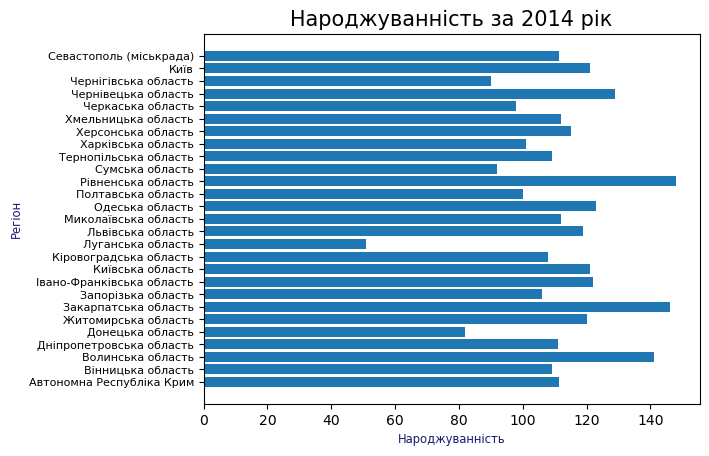

In [46]:

plt.barh(table["регіон"], table["2014"])

plt.xlabel("Народжуванність", fontsize="small", color="midnightblue")
plt.ylabel("Регіон", fontsize="small", color="midnightblue")
plt.title("Народжуванність за 2014 рік", fontsize=15)
plt.yticks(fontsize=8)
plt.show()


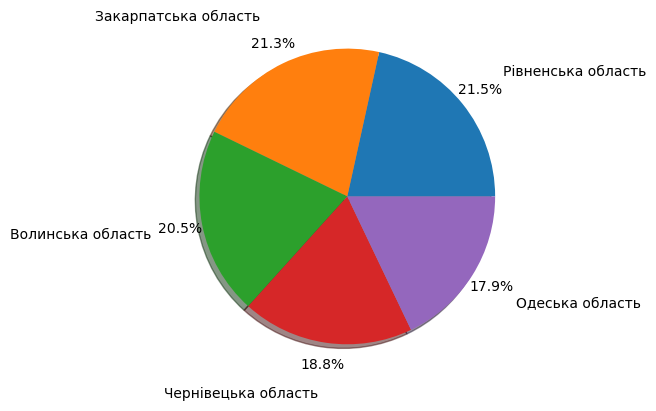

In [60]:
sort = table.sort_values("2014", ascending=False).head(5)[["регіон", "2014"]]
plt.pie(
    sort["2014"],
    labels= sort["регіон"],
    shadow=True,
    explode=[0, 0, 0, 0, 0],
    autopct="%.1f%%",
    pctdistance=1.15,
    labeldistance=1.35,
)

plt.show()

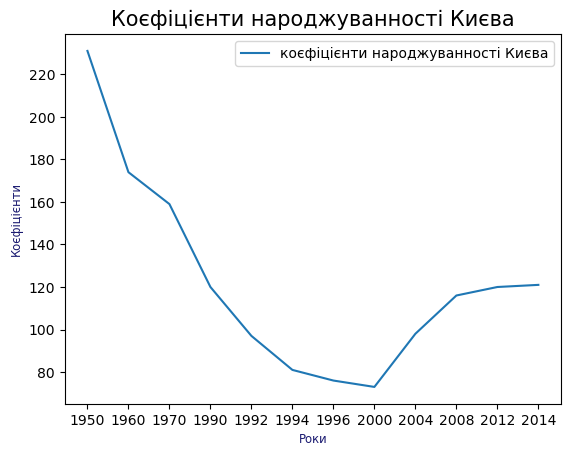

In [59]:
kyiv = table[table["регіон"] == "Київ"]
plt.plot(kyiv.columns[1:], kyiv.iloc[0][1:], label='коєфіцієнти народжуванності Києва')
plt.xlabel('Роки', fontsize='small', color='midnightblue')
plt.ylabel('Коєфіцієнти', fontsize='small', color='midnightblue')
plt.title('Коєфіцієнти народжуванності Києва', fontsize=15)
plt.legend()
plt.show()